In [1]:
import pandas as pd
import glob
import joblib
from tqdm.auto import tqdm
from cleaning import cleaning

/bsuhome/yavarpourmohamad/miniforge3/envs/ML/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Selecting Big fires

In [2]:
fpa_fod = pd.read_csv(filepath_or_buffer = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Data/FPA_FOD/FPA_FOD_Plus.csv',
                      sep = ',')

/tmp/ipykernel_12989/2279471137.py:1: DtypeWarning: Columns (9,11,13,14,15,16,17,52,53,60,62,63,64,307) have mixed types. Specify dtype option on import or set low_memory=False.
  fpa_fod = pd.read_csv(filepath_or_buffer = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Data/FPA_FOD/FPA_FOD_Plus.csv',


# test

In [3]:
states = ['WA', 'OR', 'CA', 'ID', 'NV', 'MT', 'WY', 'UT', 'AZ', 'CO', 'NM']
col = ['NWCG_GENERAL_CAUSE', 'STATE', 'FIRE_NAME', 'FIRE_SIZE',
        'DISCOVERY_DOY', 'FIRE_YEAR', 'FIPS_CODE', 'Annual_etr', 'Annual_precipitation',
        'Annual_tempreture', 'pr', 'tmmn', 'vs', 'fm100', 'fm1000', 'bi', 'vpd', 'erc', 'Elevation_1km', 'Aspect_1km', 'erc_Percentile', 'Slope_1km',
        'TPI_1km', 'EVC', 'FRG', 'Mang_Name', 'GAP_Sts', 'GDP', 'GHM', 'NPL',
        'Popo_1km', 'RPL_THEMES']
fpa_fod_w = fpa_fod.loc[fpa_fod['STATE'].isin(values = states), col]

In [4]:
labels = {'USFS': 0,
        'BLM': 1,
        'UNK': 2,
        'TRIB': 3,
        'SLB': 4,
        'SFW': 5,
        'SPR': 6,
        'SDOL': 7,
        'SDNR': 8,
        'REG': 9,
        'CITY': 10,
        'NPS': 11,
        'PVT': 12,
        'NGO': 13,
        'FWS': 14,
        'CNTY': 15,
        'USBR': 16,
        'DOD': 17,
        'UNKL': 18,
        'RWD': 19,
        'USACE': 20,
        'OTHS': 21,
        'NRCS': 22,
        'ARS': 23,
        'DOE': 24,
        'JNT': 25,
        'OTHF': 26,
        'OTHR': 27,
        'SDC': 28,
        'BPA': 29}

In [5]:
fpa_fod_w, cln_rslt = cleaning(df = fpa_fod_w)
fpa_fod_w['Mang_Name'] = fpa_fod_w['Mang_Name'].replace(to_replace = labels)

/tmp/ipykernel_12989/2532663712.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fpa_fod_w['Mang_Name'] = fpa_fod_w['Mang_Name'].replace(to_replace = labels)


In [6]:
xgb_main = joblib.load(filename = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Branching combines roadFSless/clf_xgb_main.pkl')


In [7]:
prob = xgb_main.predict_proba(fpa_fod_w[fpa_fod_w.columns[4:]])
prob = pd.DataFrame(data = prob, columns = ['No_fire', 'Fire probability'])

In [8]:
fpa_fod_w['Fire probability'] = prob['Fire probability']

In [9]:
indices = []
for cause in fpa_fod_w.NWCG_GENERAL_CAUSE.unique():
    idmx = fpa_fod_w.loc[(fpa_fod_w['NWCG_GENERAL_CAUSE'] == cause) & (~fpa_fod_w['FIPS_CODE'].isna()), 'Fire probability'].idxmax()
    indices.append(idmx)

# continue

In [10]:
states = ['WA', 'OR', 'CA', 'ID', 'NV', 'MT', 'WY', 'UT', 'AZ', 'CO', 'NM']
indices = []
for cause in fpa_fod.NWCG_GENERAL_CAUSE.unique():
    idmx = fpa_fod.loc[(fpa_fod['NWCG_GENERAL_CAUSE'] == cause) & (~fpa_fod['FIPS_CODE'].isna() & (fpa_fod['STATE'].isin(values = states))), 'FIRE_SIZE'].idxmax()
    indices.append(idmx)

In [11]:
# fpa_fod_bigs = fpa_fod.loc[indices, ['NWCG_GENERAL_CAUSE', 'STATE', 'FIRE_NAME', 'FIPS_CODE', 'LATITUDE', 'LONGITUDE', 'DISCOVERY_DATE']]
# fpa_fod_bigs.to_csv(path_or_buf = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Big_fires_history_2nd/bigs.csv',
#                     sep = ',', index = False)
fpa_fod_bigs = pd.read_csv(filepath_or_buffer = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Big_fires_history_2nd/bigs.csv',
                           sep = ',')

In [12]:
fname = fpa_fod_bigs['FIRE_NAME'].to_list()
fdate = fpa_fod_bigs['DISCOVERY_DATE'].to_list()
indices = fpa_fod[(fpa_fod['FIRE_NAME'].isin(fname)) & (fpa_fod['DISCOVERY_DATE'].isin(fdate))].index.to_list()

# Aggregating the values

In [13]:
csv_list = glob.glob(pathname = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Big_fires_history_2nd/extraction/Output/*.csv')
csv_list.remove('/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Big_fires_history_2nd/extraction/Output/sample_gridmet.csv')
map_data = pd.read_csv(filepath_or_buffer = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Big_fires_history_2nd/extraction/bigs_data.csv',
                       sep = ',')
cols = ['STATE', 'FIRE_NAME', 'DISCOVERY_DOY', 'FIRE_YEAR', 'DISCOVERY_DATE', 'FIPS_CODE', 'LATITUDE', 'LONGITUDE']
for csv in tqdm(csv_list):
    temp = pd.read_csv(filepath_or_buffer = csv, sep = ',')
    map_data = pd.merge(left = map_data,
                        right = temp,
                        how  = 'left',
                        on = cols)
    map_data = map_data.drop_duplicates(subset = cols, keep = 'first')
# map_data = map_data.drop(columns = 'DISCOVERY_DATE')
map_data['NPL'] = pd.read_csv(filepath_or_buffer = csv_list[5])['NPL']

100%|██████████| 8/8 [00:02<00:00,  2.87it/s]


# Combining

In [14]:
col = ['DISCOVERY_DOY', 'FIRE_YEAR', 'FIPS_CODE', 'Annual_etr', 'Annual_precipitation',
       'Annual_tempreture', 'pr', 'tmmn', 'vs', 'fm100', 'fm1000', 'bi', 'vpd', 'erc', 'Elevation_1km', 'Aspect_1km', 'erc_Percentile', 'Slope_1km',
       'TPI_1km', 'EVC', 'FRG', 'Mang_Name', 'GAP_Sts', 'GDP', 'GHM', 'NPL', 'Popo_1km', 'RPL_THEMES']
mpdt_cols = map_data.columns.to_list()
cols2import = [x for x in col if x not in mpdt_cols]

In [15]:
fpa_fod2add = fpa_fod.loc[indices, ['NWCG_GENERAL_CAUSE'] + cols + cols2import]

In [16]:
final = pd.merge(left = map_data,
                 right = fpa_fod2add,
                 on = ['FIRE_NAME'],
                 how = 'left')
final = final.rename(columns = {'STATE_x': 'STATE',
                                'LONGITUDE_x': 'LONGITUDE',
                                'LATITUDE_x': 'LATITUDE',
                                'DISCOVERY_DATE_x': 'DISCOVERY_DATE',
                                'DISCOVERY_DOY_x': 'DISCOVERY_DOY',
                                'FIRE_YEAR_x': 'FIRE_YEAR',
                                'FIPS_CODE_x': 'FIPS_CODE'})
final = final.drop(columns = ['STATE_y', 'DISCOVERY_DOY_y', 'FIRE_YEAR_y', 'DISCOVERY_DATE_y', 
                              'FIPS_CODE_y', 'LATITUDE_y', 'LONGITUDE_y'])

# Add Fire Probability

In [17]:
final_cln, cln_rslt = cleaning(df = final.copy(deep = True))
cols = ['NWCG_GENERAL_CAUSE', 'STATE', 'FIRE_NAME', 'LONGITUDE', 'LATITUDE', 'DISCOVERY_DATE',
        'DISCOVERY_DOY', 'FIRE_YEAR', 'FIPS_CODE', 'Annual_etr', 'Annual_precipitation',
        'Annual_tempreture', 'pr', 'tmmn', 'vs', 'fm100', 'fm1000', 'bi', 'vpd', 'erc', 'Elevation_1km', 'Aspect_1km', 'erc_Percentile', 'Slope_1km',
        'TPI_1km', 'EVC', 'FRG', 'Mang_Name', 'GAP_Sts', 'GDP', 'GHM', 'NPL', 'Popo_1km', 'RPL_THEMES']
final_cln = final_cln[cols]
final_cln['Mang_Name'] = final_cln['Mang_Name'].replace(to_replace = labels)

/tmp/ipykernel_12989/2152573484.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_cln['Mang_Name'] = final_cln['Mang_Name'].replace(to_replace = labels)


In [18]:
final_cln[['Annual_etr', 'Annual_precipitation']] = final_cln[['Annual_etr', 'Annual_precipitation']].astype(int)
final_cln['Annual_tempreture'] = final_cln['Annual_tempreture'].round(0).astype(int)

In [19]:
xgb_main = joblib.load(filename = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Branching combines roadFSless/clf_xgb_main_2000.pkl')
xgb_H = joblib.load(filename = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Branching combines roadFSless/clf_xgb_H_2000.pkl')
xgb_N = joblib.load(filename = '/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Branching combines roadFSless/clf_xgb_N_2000.pkl')

In [20]:
prob = xgb_main.predict_proba(final_cln[final_cln.columns[6:]])
prob_N = xgb_main.predict_proba(final_cln.loc[final_cln['NWCG_GENERAL_CAUSE'] == 'Natural', final_cln.columns[6:]])
prob_H = xgb_main.predict_proba(final_cln.loc[final_cln['NWCG_GENERAL_CAUSE'] != 'Natural', final_cln.columns[6:]])
prob = pd.DataFrame(data = prob, columns = ['No_fire', 'Fire probability'])
prob_N = pd.DataFrame(data = prob_N, columns = ['No_fire', 'Fire probability'])
prob_H = pd.DataFrame(data = prob_H, columns = ['No_fire', 'Fire probability'])

In [21]:
final_dt = final_cln.copy(deep = True)
final_dt['Fire probability_main'] = (prob['Fire probability'].values * 100).round(1)
final_dt.loc[final_dt['NWCG_GENERAL_CAUSE'] == 'Natural', 'Fire probability'] = (prob_N['Fire probability'].values * 100).round(1)
final_dt.loc[final_dt['NWCG_GENERAL_CAUSE'] != 'Natural', 'Fire probability'] = (prob_H['Fire probability'].values * 100).round(1)
final_dt['DISCOVERY_DATE'] = pd.to_datetime(final_dt['DISCOVERY_DATE'])

In [22]:
final_dt = final_dt[final_dt['FIRE_YEAR'] > 1999]

# Plotting

In [23]:
import matplotlib.pyplot as plt
import numpy as np

Text(0.5, 1.0, 'All vs Human')

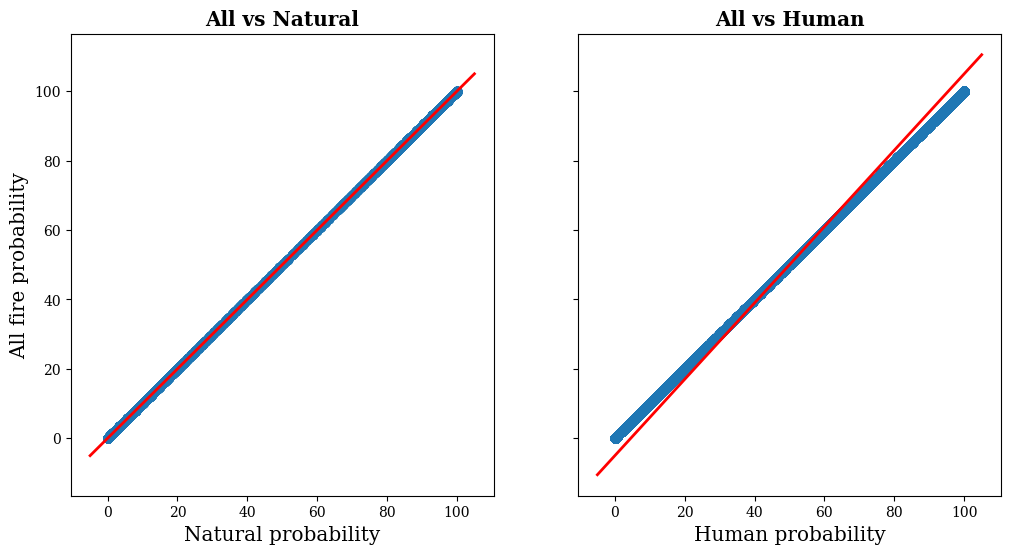

In [24]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 6), sharey = True, sharex = False)
axes[0].scatter('Fire probability', 'Fire probability_main', data = final_dt[final_dt['NWCG_GENERAL_CAUSE'] == 'Natural'], marker = 'o')
axes[1].scatter('Fire probability', 'Fire probability_main', data = final_dt[final_dt['NWCG_GENERAL_CAUSE'] != 'Natural'], marker = 'o')
axes[0].set_xlabel('Natural probability', fontsize = 'x-large')
axes[0].set_ylabel('All fire probability', fontsize = 'x-large')
axes[1].set_xlabel('Human probability', fontsize = 'x-large')
for ax in axes:
    ax.plot(ax.get_xlim(), ax.get_ylim(), color = 'red', linestyle = '-', linewidth = 2)
axes[0].set_title('All vs Natural', fontsize = 'x-large', fontweight = 'bold')
axes[1].set_title('All vs Human', fontsize = 'x-large', fontweight = 'bold')

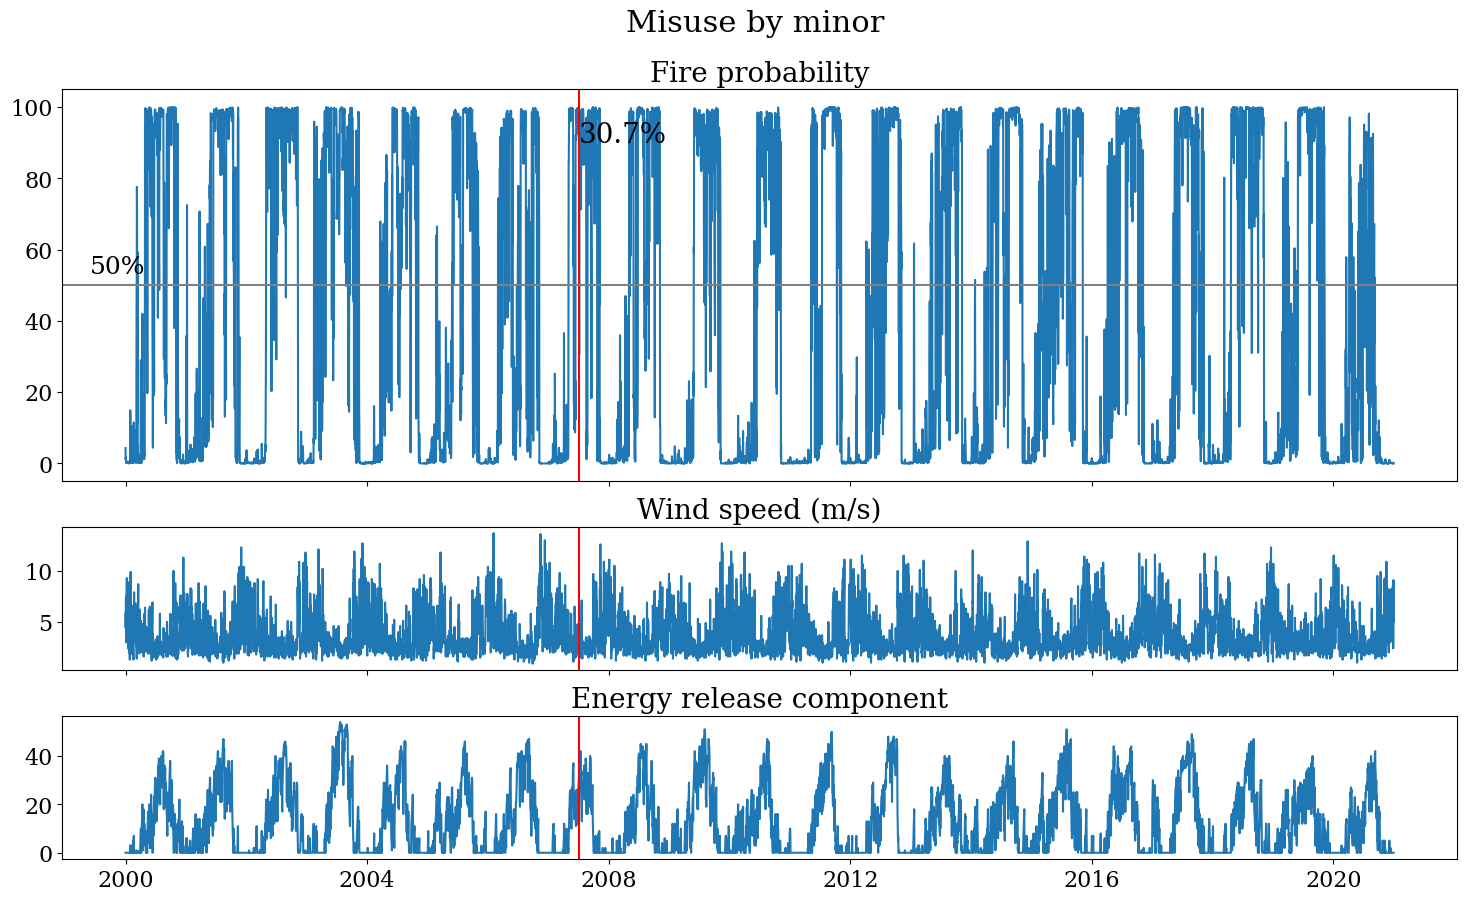

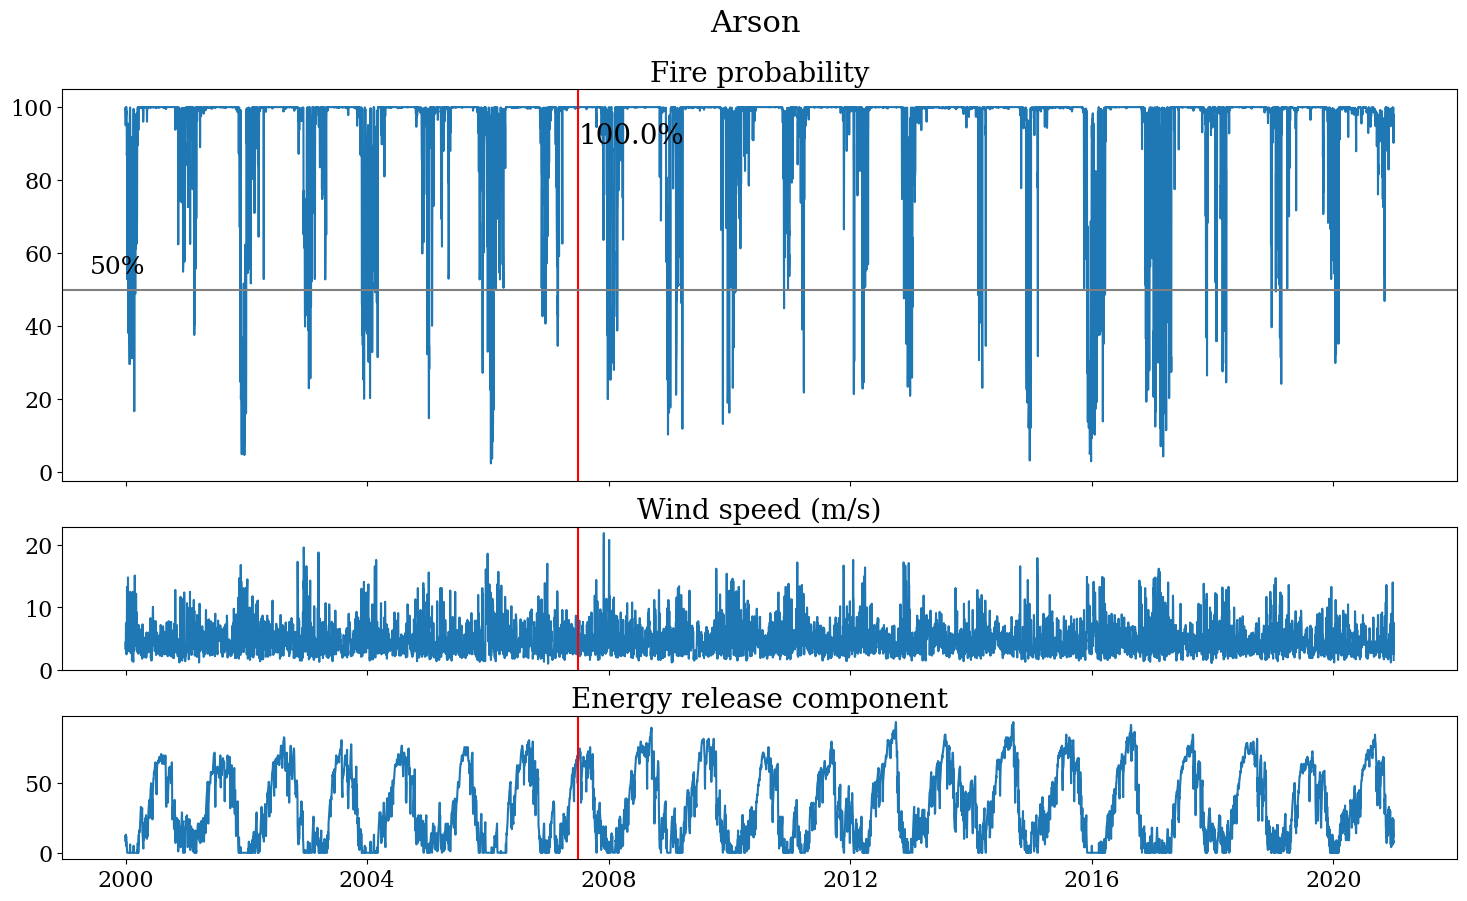

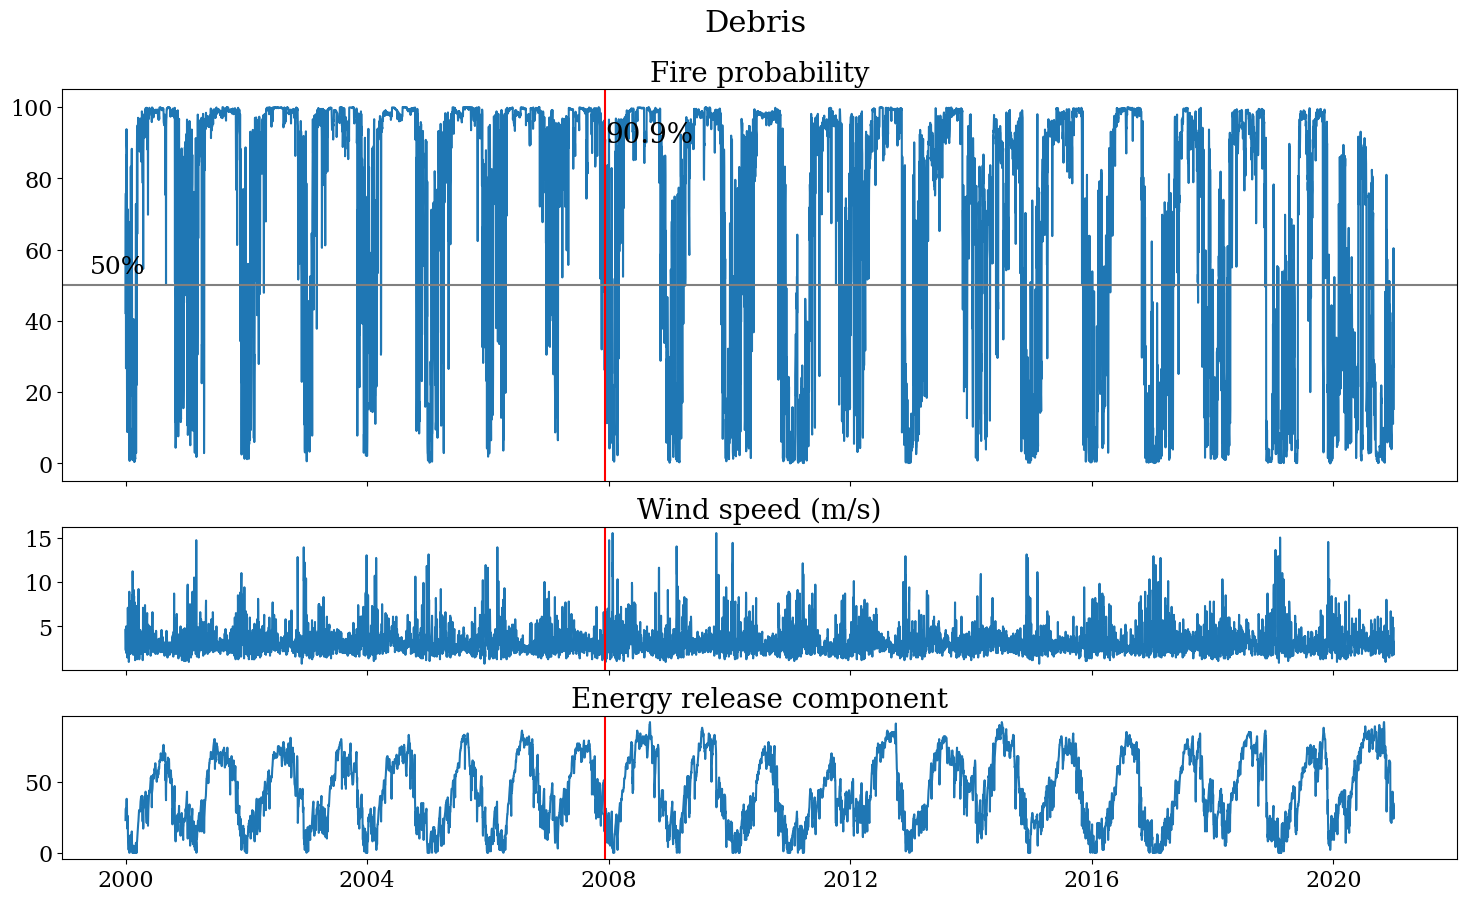

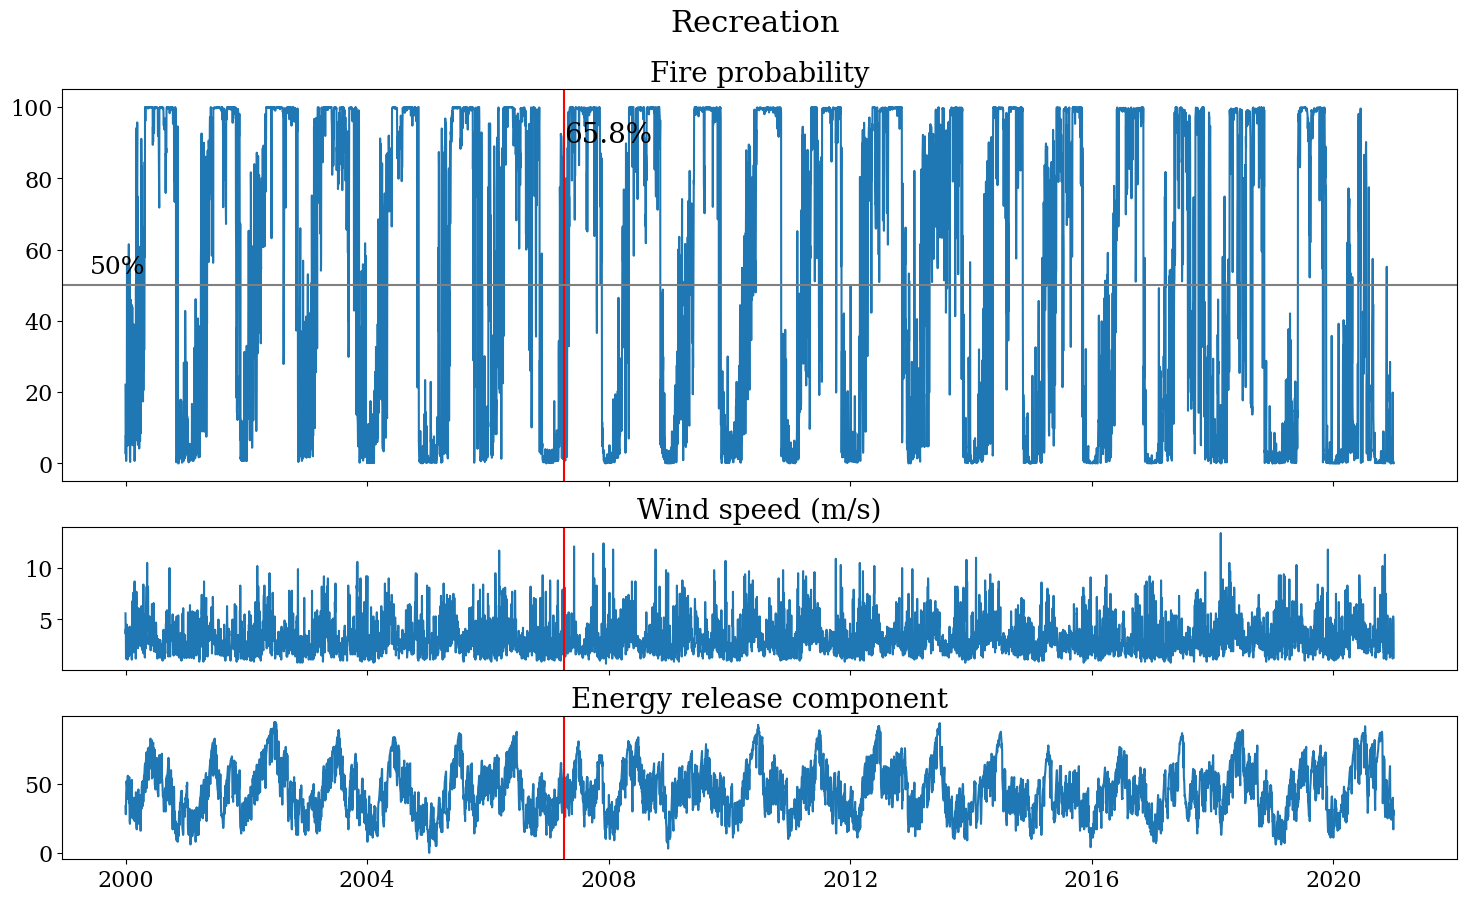

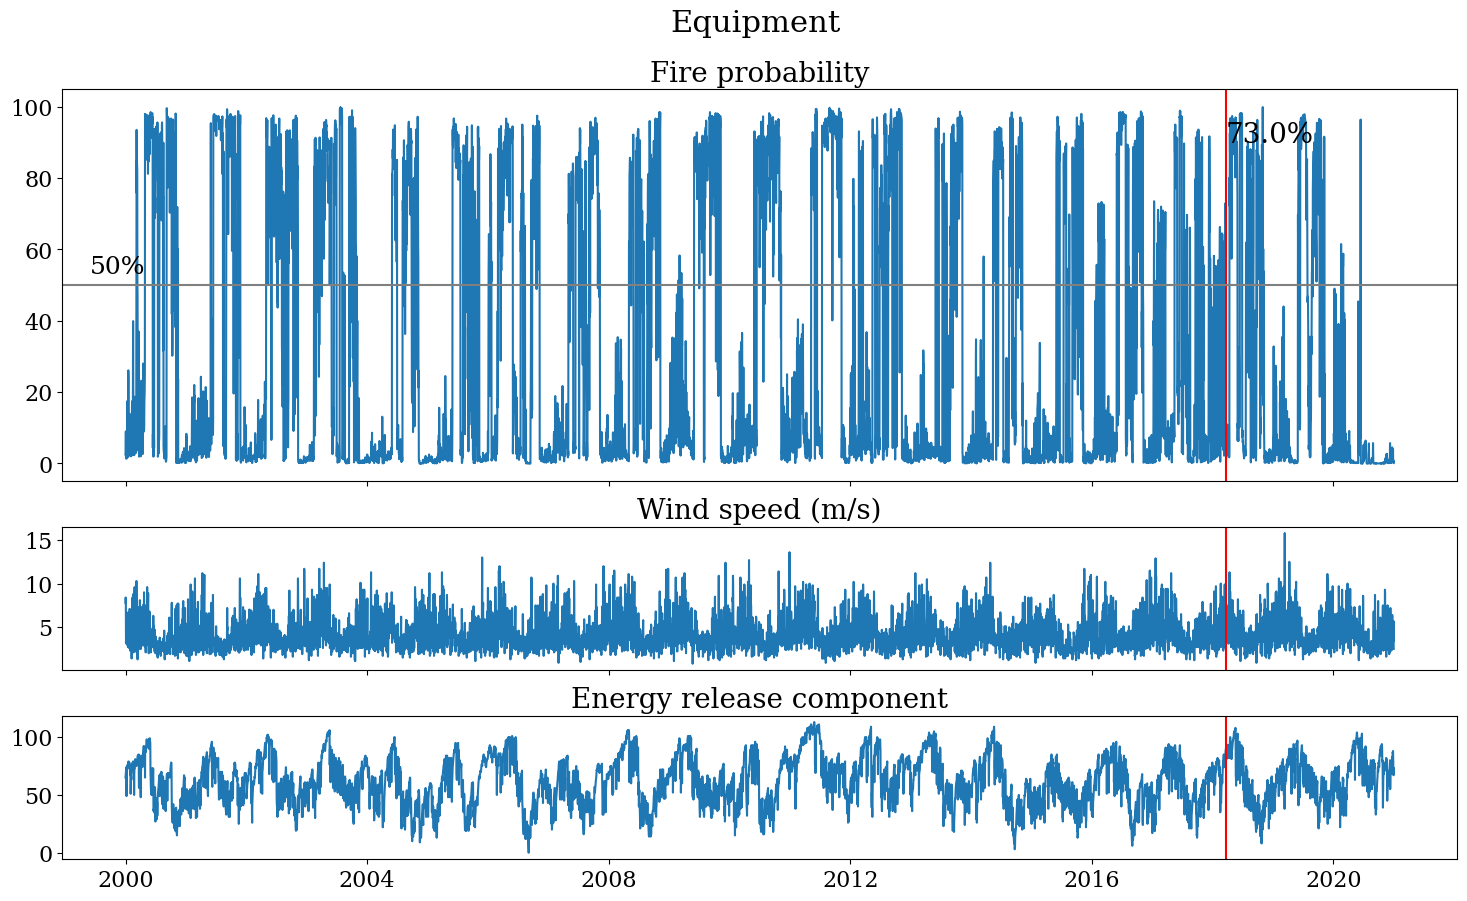

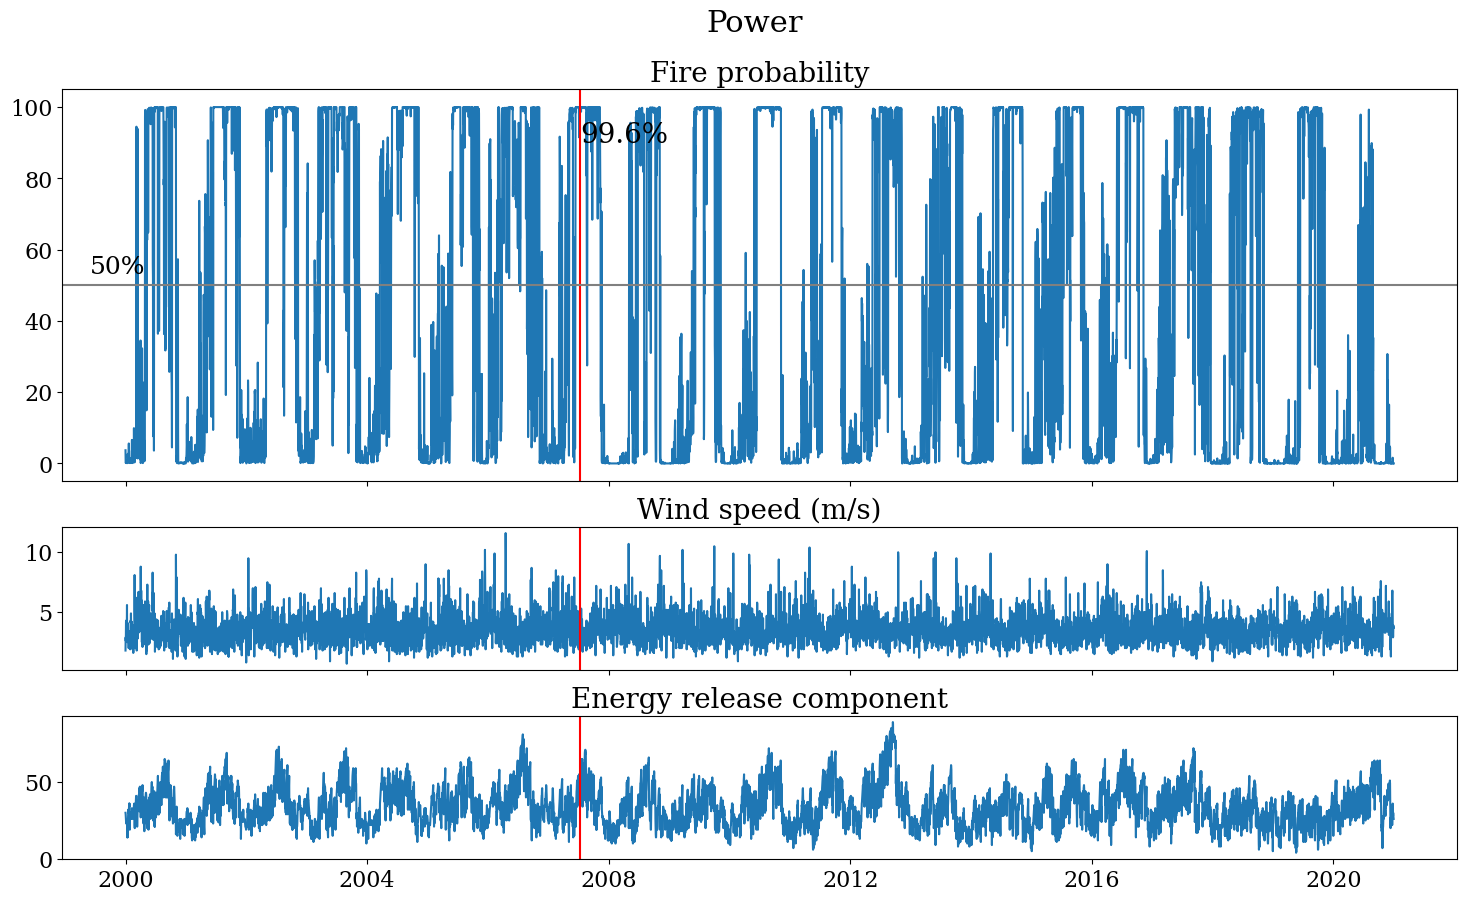

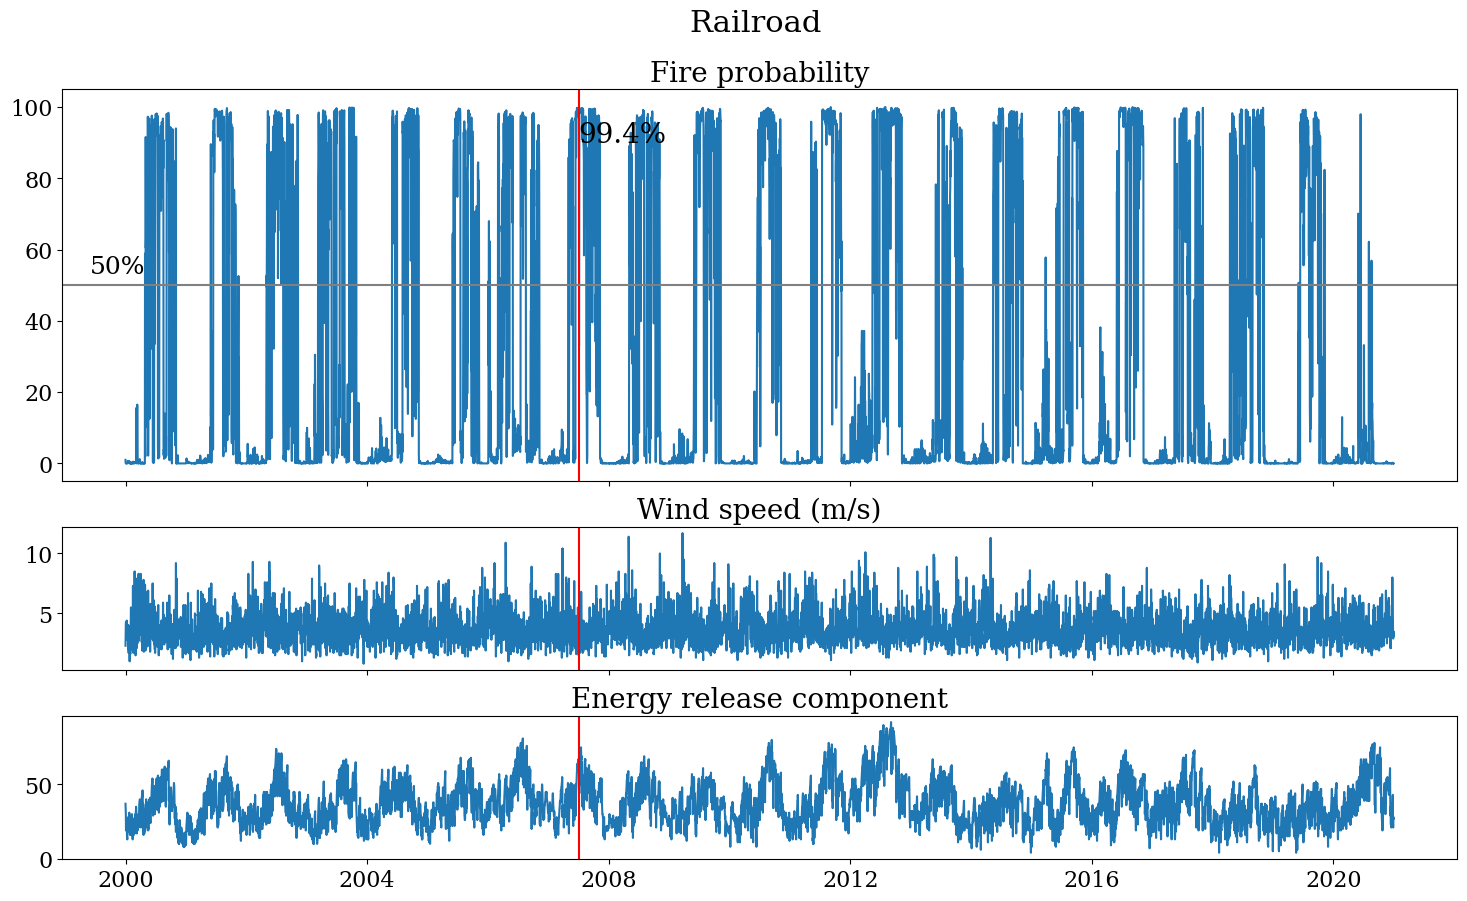

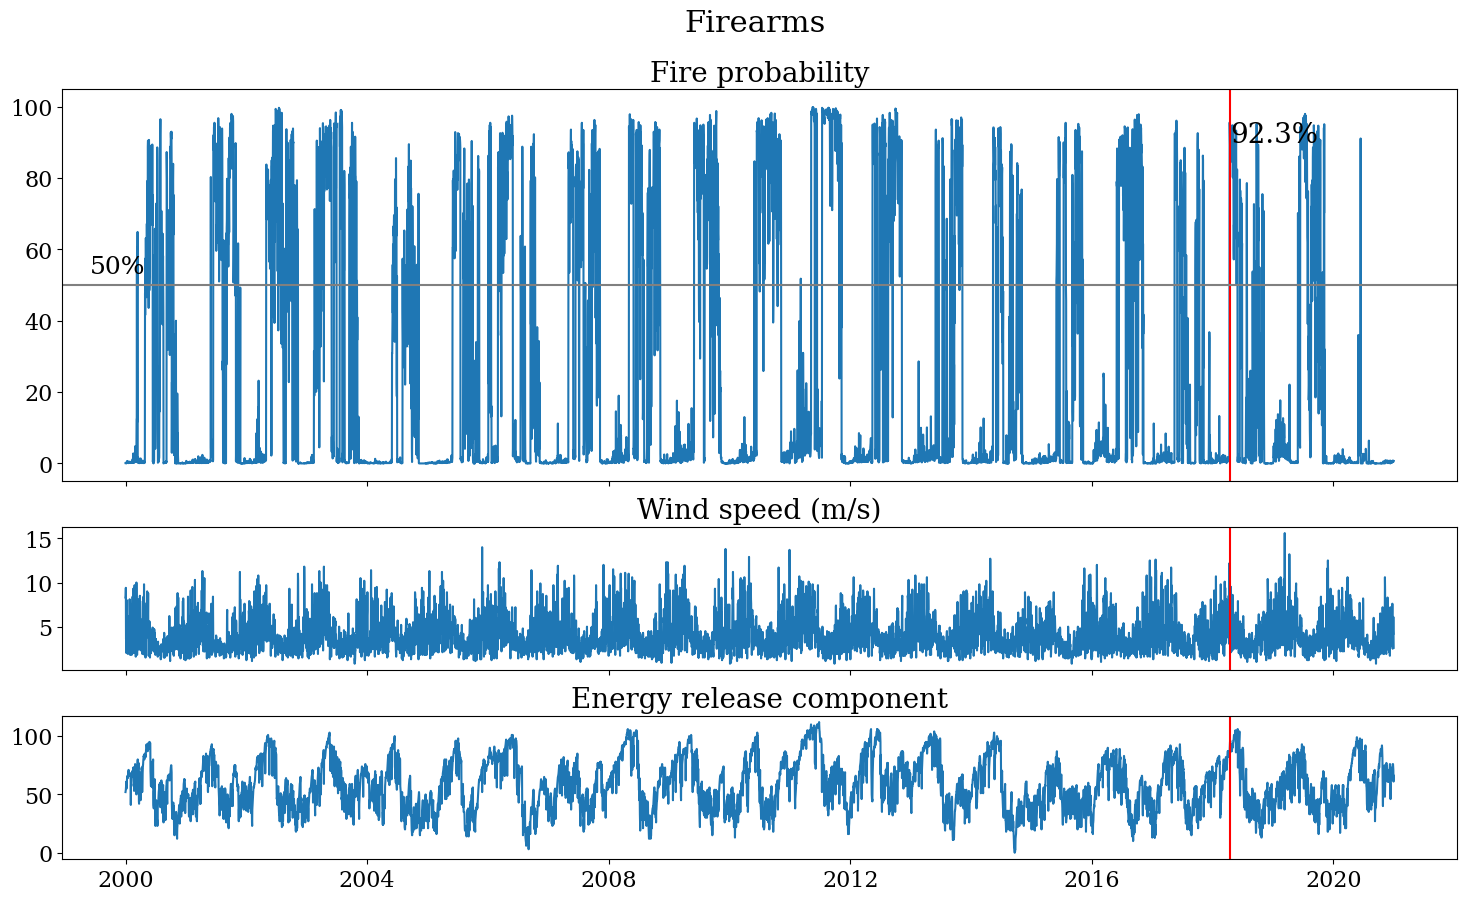

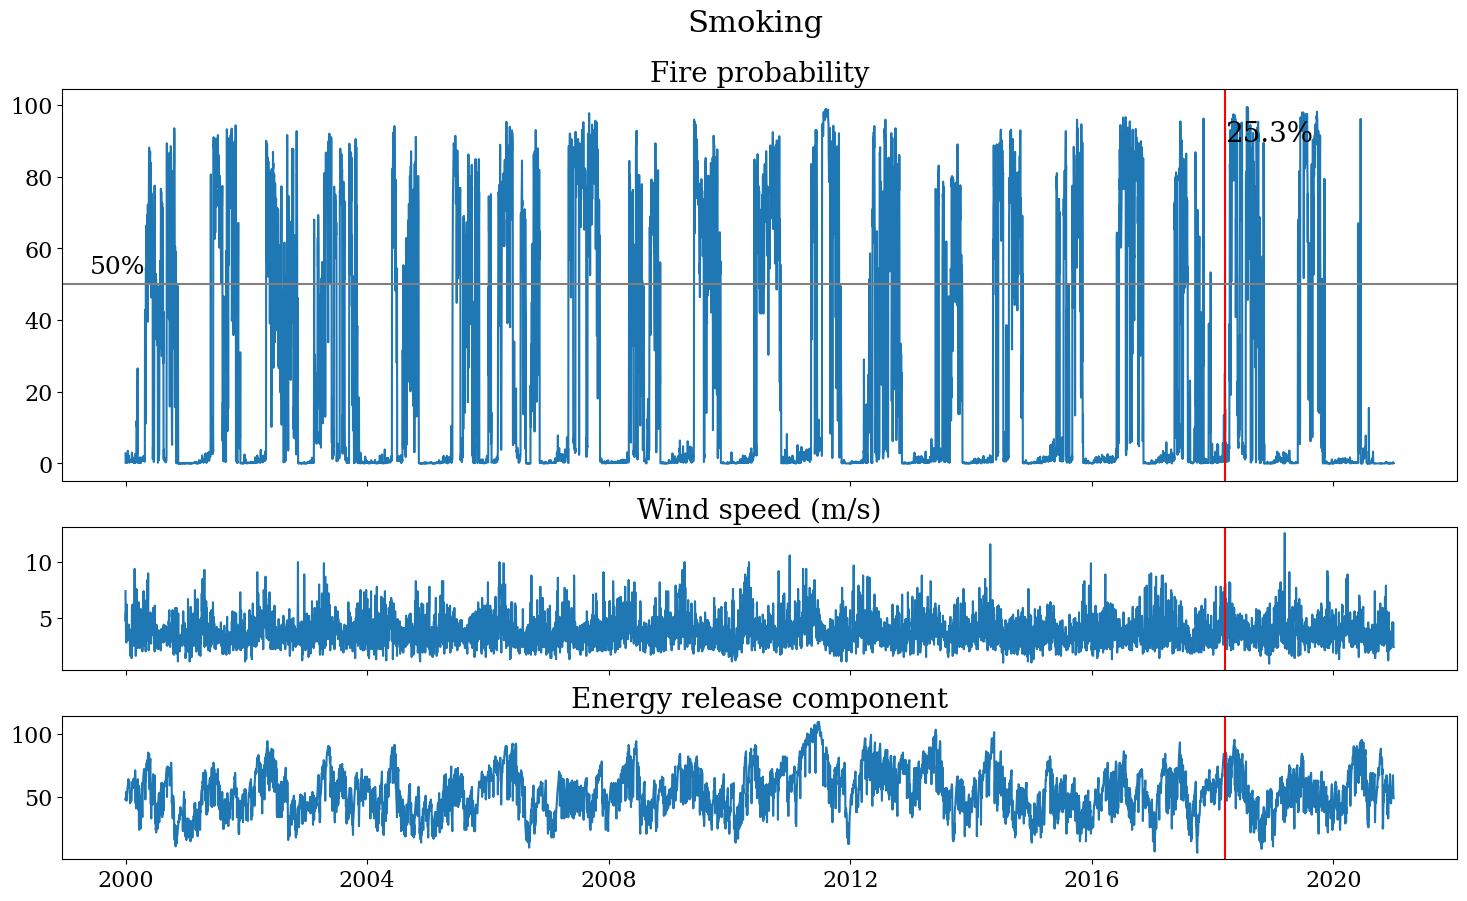

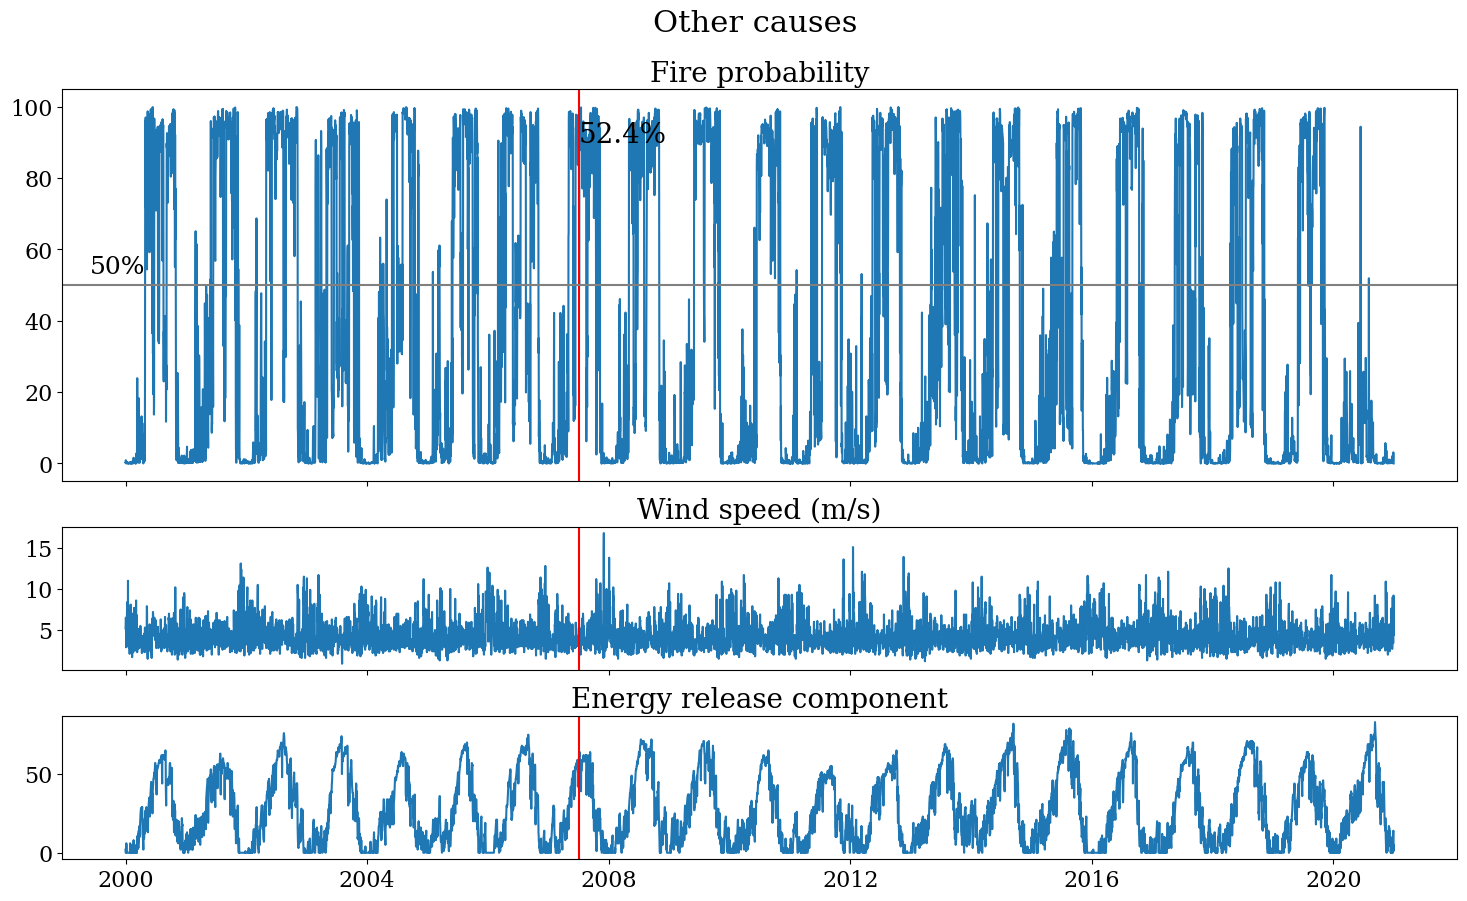

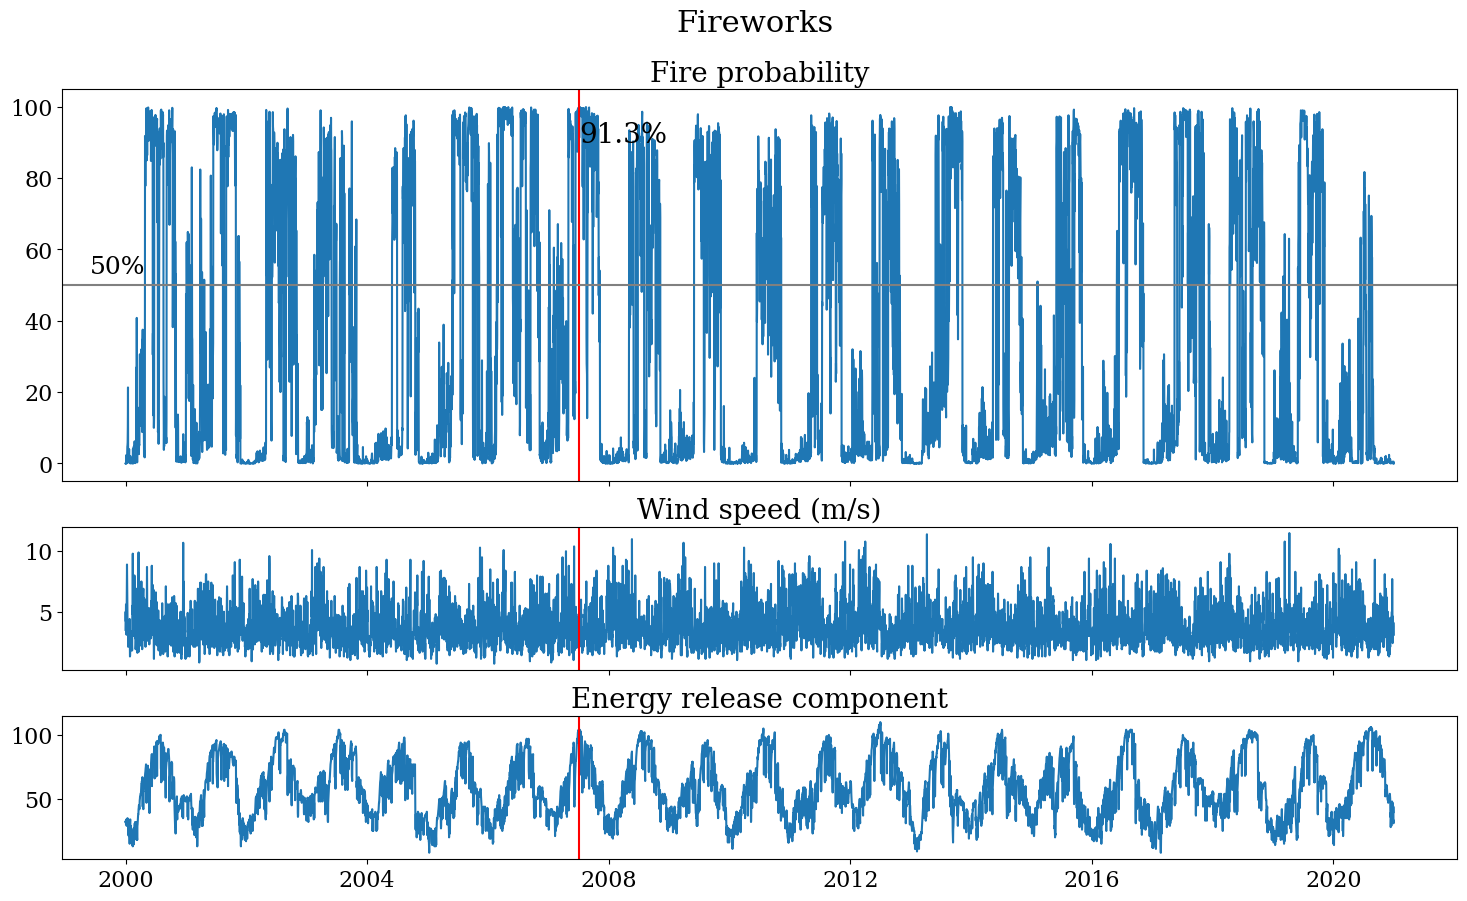

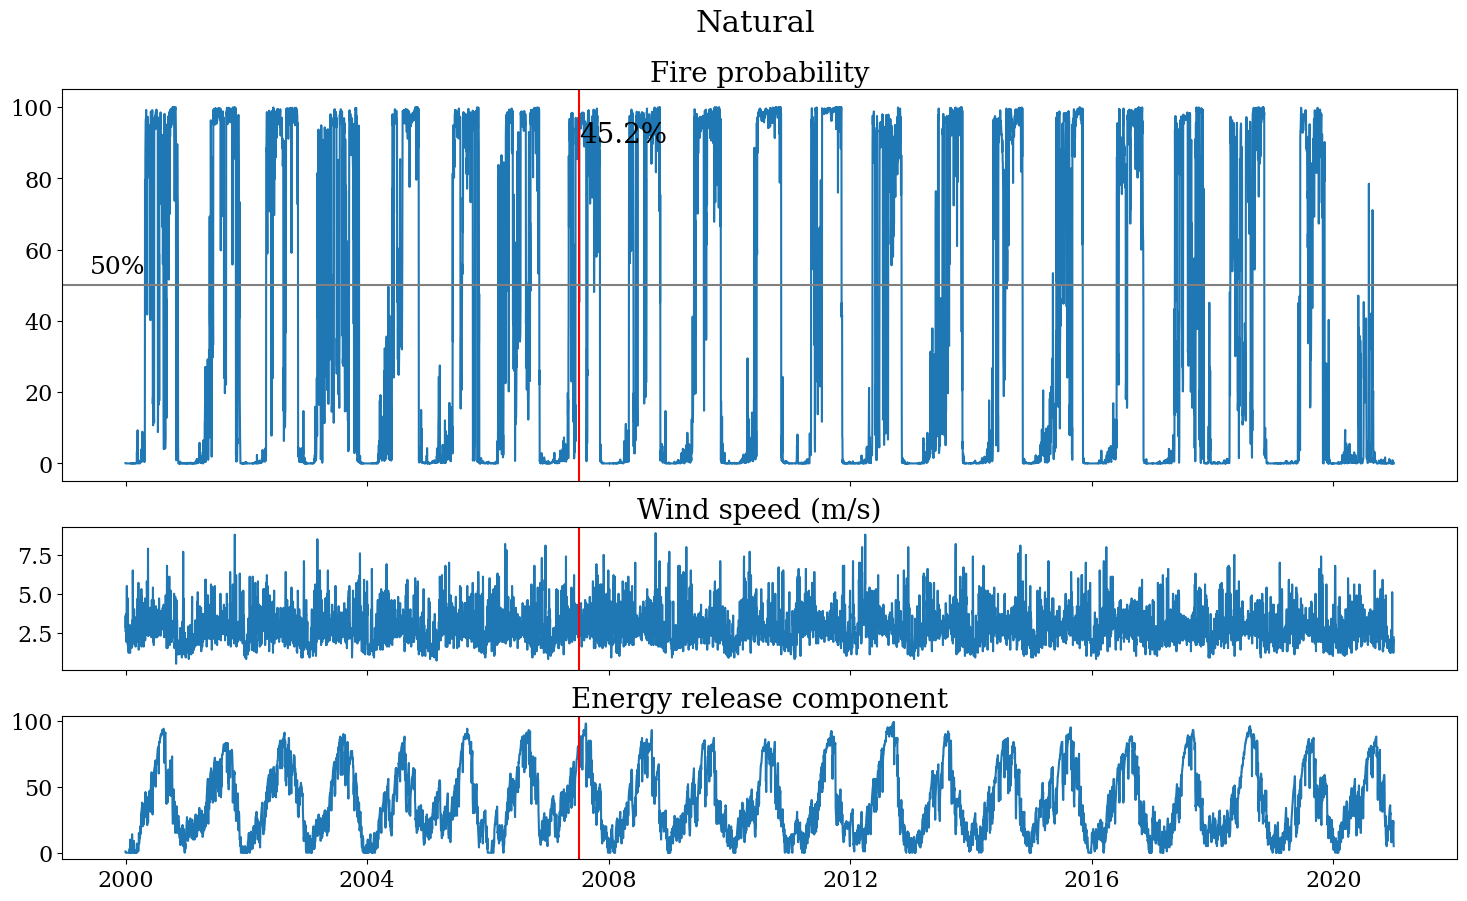

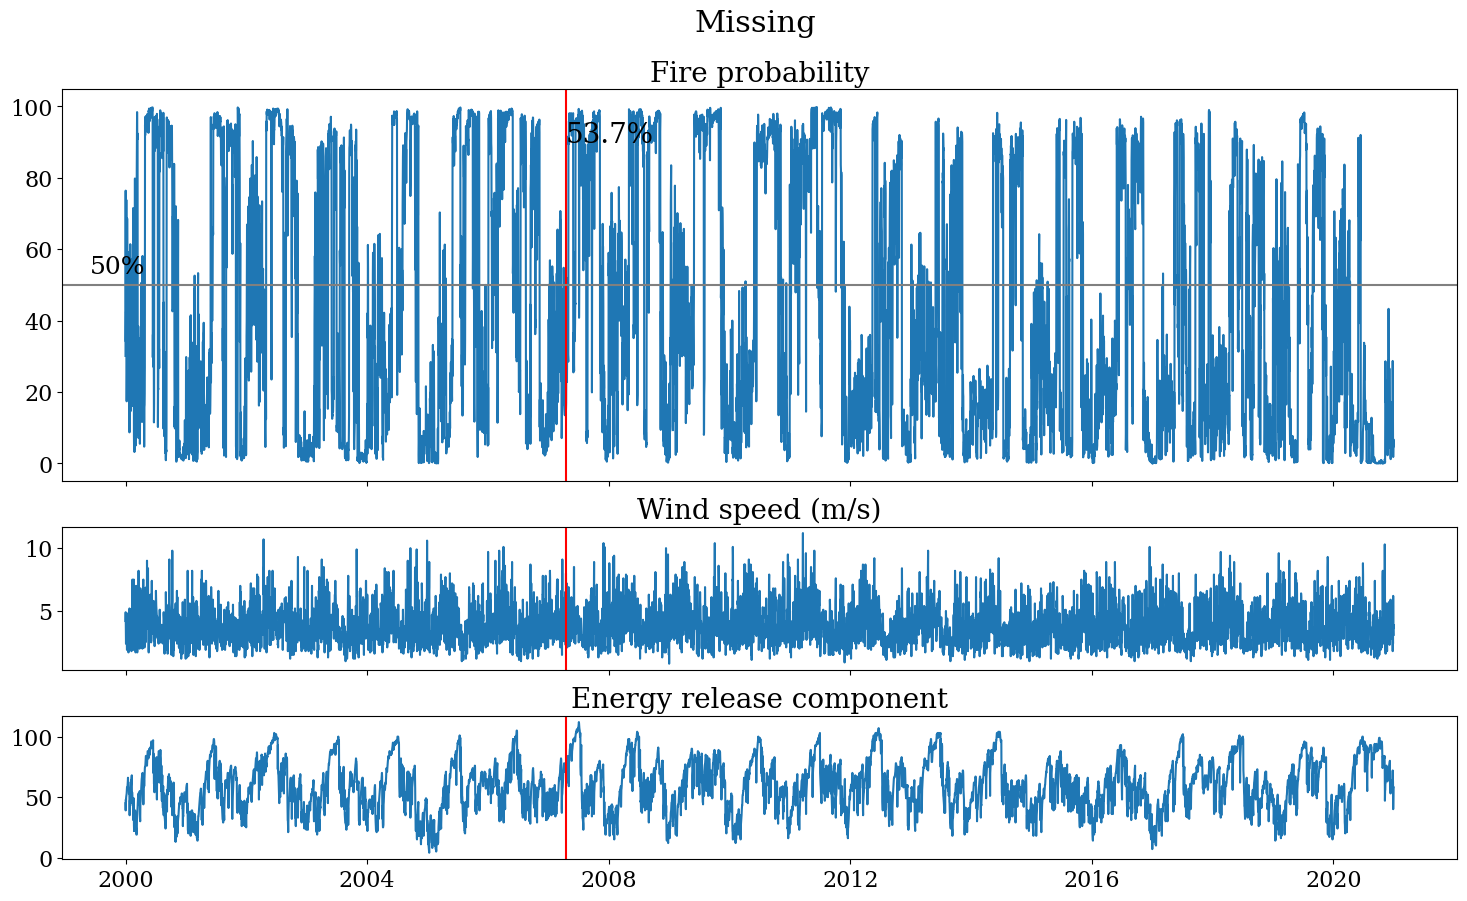

In [25]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
variables = {'Fire probability': 'Fire probability',
             'vs': 'Wind speed (m/s)',
             'erc': 'Energy release component',
            #  'fm100': '100-hour dead fuel moisture (%)',
            #  'vpd': 'Vapor pressure deficit (kPa)',
            #  'erc_Percentile': 'erc_Percentile',
            #  'NPL': 'National Preparedness Level'
             }
cause_abv = {'Misuse of fire by a minor': 'Misuse by minor',
             'Arson/incendiarism': 'Arson',
             'Debris and open burning': 'Debris',
             'Recreation and ceremony': 'Recreation',
             'Equipment and vehicle use': 'Equipment',
             'Power generation/transmission/distribution': 'Power',
             'Railroad operations and maintenance': 'Railroad',
             'Firearms and explosives use': 'Firearms',
             'Smoking': 'Smoking',
             'Other causes': 'Other causes',
             'Fireworks': 'Fireworks',
             'Natural': 'Natural',
             'Missing data/not specified/undetermined': 'Missing'}
for name in list(cause_abv.keys()):
    info = fpa_fod_bigs[fpa_fod_bigs['NWCG_GENERAL_CAUSE'] == name]    
    dt2plt = final_dt[final_dt['NWCG_GENERAL_CAUSE'] == name]
    dt2plt = dt2plt.sort_values(by = 'DISCOVERY_DATE')
    fig_height = 10
    i = 0
    fig, axs = plt.subplots(nrows = len(variables), ncols = 1,
                            sharex = True, figsize = (18, fig_height), gridspec_kw={'height_ratios': [3, 1.1, 1.1]})
    for var in variables.keys():
        axs[i].plot(dt2plt['DISCOVERY_DATE'], dt2plt[var])
        axs[i].set_title(f'{variables[var]}', fontsize=20)
        axs[i].axvline(x = info.DISCOVERY_DATE, color = 'red')
        axs[i].tick_params(axis='both', which='major', labelsize=16)
        if var == 'Fire probability':
            axs[i].axhline(y = 50, color = 'grey')
            axs[i].text(x = 0.02, y = 0.53, s = '50%', color = '#000000',
                        fontsize = 18,
                        transform = axs[i].transAxes)
            axs[i].text(x = info.DISCOVERY_DATE, y = 90,
                        color = '#000000',
                        fontsize = 20,
                        s = str(dt2plt.loc[dt2plt['DISCOVERY_DATE'] == info.DISCOVERY_DATE.values[0], 'Fire probability'].values[0])+'%')
        i += 1
    plt.suptitle(t = f'{cause_abv[name]}', x = 0.51, y = 0.96, fontsize = 22)
    # fig.savefig(fname = f'/bsuhome/yavarpourmohamad/scratch/Dissertation/Code/Big_fires_history_2nd/plots/{cause_abv[name]}.png')